# Эксперимент 03: Embeddings поиск и сравнение с TF-IDF

**Цель:** Построить семантический поиск на sentence-transformers и сравнить его с TF-IDF.

**Используемые данные:** 29 чанков из `data/` (ml_docs + python_docs)

**Основные выводы:** Embeddings понимают смысл запроса, TF-IDF работает только по точному совпадению слов. На синонимах и перефразировках embeddings выигрывают.

---

## 1. Загрузка данных и обучение обеих моделей

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.data.loader import load_and_chunk_documents
from src.models.tfidf_search import TFIDFSearch
from src.models.embedding_search import EmbeddingSearch

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

chunks = load_and_chunk_documents('../data')
print(f'Загружено чанков: {len(chunks)}')

Загружено чанков: 29


In [2]:
# Обучаем TF-IDF (быстро)
tfidf = TFIDFSearch()
tfidf.fit(chunks)

TF-IDF модель обучена.
  Чанков в индексе: 29
  Размер словаря: 3820 слов


In [3]:
# Обучаем Embeddings (первый раз скачает модель ~90 МБ, потом быстро)
emb = EmbeddingSearch(model_name='all-MiniLM-L6-v2')
emb.fit(chunks)

Загрузка модели all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Создание эмбеддингов для 29 чанков...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Готово! Размер матрицы эмбеддингов: (29, 384)


## 2. Прямое сравнение на одних и тех же запросах

In [4]:
def compare(query: str, top_k: int = 3):
    """Выводит результаты TF-IDF и Embeddings рядом для одного запроса."""
    print(f'\nЗапрос: "{query}"')
    print('=' * 70)
    
    r_tfidf = tfidf.search(query, top_k=top_k)
    r_emb   = emb.search(query, top_k=top_k)
    
    print(f'{"TF-IDF":^35} | {"Embeddings":^35}')
    print('-' * 70)
    
    for i in range(top_k):
        t = r_tfidf[i] if i < len(r_tfidf) else None
        e = r_emb[i]   if i < len(r_emb)   else None
        
        t_str = f"{t['filename']} ({t['score']:.3f})" if t else '-'
        e_str = f"{e['filename']} ({e['score']:.3f})" if e else '-'
        
        print(f'#{i+1} {t_str:<33} | #{i+1} {e_str}')

In [5]:
# Запрос 1: точные слова — оба метода должны справиться
compare('переобучение регуляризация dropout')


Запрос: "переобучение регуляризация dropout"
              TF-IDF                |             Embeddings             
----------------------------------------------------------------------
#1 overfitting.txt (0.109)           | #1 underfitting.txt (0.410)
#2 underfitting.txt (0.091)          | #2 underfitting.txt (0.404)
#3 underfitting.txt (0.069)          | #3 train_test_split.txt (0.388)


In [6]:
# Запрос 2: перефразировка — embeddings должны справиться лучше
# "модель запоминает данные" = переобучение, но слова другие
compare('модель запоминает данные вместо обобщения')


Запрос: "модель запоминает данные вместо обобщения"
              TF-IDF                |             Embeddings             
----------------------------------------------------------------------
#1 train_test_split.txt (0.159)      | #1 regression.txt (0.503)
#2 underfitting.txt (0.048)          | #2 overfitting.txt (0.482)
#3 train_test_split.txt (0.027)      | #3 underfitting.txt (0.481)


In [7]:
# Запрос 3: английский термин + русский контекст
compare('bias variance tradeoff компромисс')


Запрос: "bias variance tradeoff компромисс"
              TF-IDF                |             Embeddings             
----------------------------------------------------------------------
#1 underfitting.txt (0.178)          | #1 underfitting.txt (0.386)
#2 underfitting.txt (0.052)          | #2 neural_networks.txt (0.357)
#3 -                                 | #3 train_test_split.txt (0.332)


In [8]:
# Запрос 4: вопрос в свободной форме
compare('как разделить данные для обучения и тестирования')


Запрос: "как разделить данные для обучения и тестирования"
              TF-IDF                |             Embeddings             
----------------------------------------------------------------------
#1 train_test_split.txt (0.167)      | #1 train_test_split.txt (0.559)
#2 underfitting.txt (0.058)          | #2 overfitting.txt (0.506)
#3 neural_networks.txt (0.053)       | #3 underfitting.txt (0.505)


In [9]:
# Запрос 5: про Python
compare('как обработать ошибку в коде на python')


Запрос: "как обработать ошибку в коде на python"
              TF-IDF                |             Embeddings             
----------------------------------------------------------------------
#1 string_methods.txt (0.089)        | #1 os_path.txt (0.505)
#2 introduction.txt (0.085)          | #2 functions.txt (0.474)
#3 introduction.txt (0.079)          | #3 classes.txt (0.449)


## 3. Формальное сравнение качества (Hit@3)

In [10]:
# Те же тестовые случаи что и в exp02
test_cases = [
    ('переобучение регуляризация dropout',        'overfitting.txt'),
    ('недообучение bias variance tradeoff',       'underfitting.txt'),
    ('классификация accuracy precision recall',   'classification.txt'),
    ('регрессия MAE MSE R2',                      'regression.txt'),
    ('train test split кросс-валидация',          'train_test_split.txt'),
    ('нейронная сеть backpropagation adam',       'neural_networks.txt'),
    ('эмбеддинги sentence transformers cosine',  'embeddings.txt'),
    ('функции python lambda аргументы',           'functions.txt'),
    ('список словарь tuple set python',           'data_structures.txt'),
    ('классы наследование init python',           'classes.txt'),
    # Дополнительные — перефразировки
    ('модель запоминает вместо обобщения',        'overfitting.txt'),
    ('как разделить данные на train и test',      'train_test_split.txt'),
    ('числовое представление текста вектор',      'embeddings.txt'),
]

rows = []
tfidf_hits = 0
emb_hits = 0

for query, expected in test_cases:
    rt = tfidf.search(query, top_k=3)
    re = emb.search(query, top_k=3)
    
    t_hit = expected in [r['filename'] for r in rt]
    e_hit = expected in [r['filename'] for r in re]
    
    if t_hit: tfidf_hits += 1
    if e_hit: emb_hits += 1
    
    rows.append({
        'query': query[:38] + '..' if len(query) > 38 else query,
        'expected': expected,
        'tfidf': '✓' if t_hit else '✗',
        'emb':   '✓' if e_hit else '✗',
    })

df_eval = pd.DataFrame(rows)
print(df_eval.to_string(index=False))
n = len(test_cases)
print(f'\nTF-IDF  Hit@3: {tfidf_hits}/{n} = {tfidf_hits/n:.0%}')
print(f'Embeddings Hit@3: {emb_hits}/{n} = {emb_hits/n:.0%}')

                                   query             expected tfidf emb
      переобучение регуляризация dropout      overfitting.txt     ✓   ✗
     недообучение bias variance tradeoff     underfitting.txt     ✓   ✓
классификация accuracy precision recal..   classification.txt     ✓   ✓
                    регрессия MAE MSE R2       regression.txt     ✓   ✓
        train test split кросс-валидация train_test_split.txt     ✓   ✓
     нейронная сеть backpropagation adam  neural_networks.txt     ✓   ✓
эмбеддинги sentence transformers cosin..       embeddings.txt     ✓   ✓
         функции python lambda аргументы        functions.txt     ✓   ✓
         список словарь tuple set python  data_structures.txt     ✓   ✓
         классы наследование init python          classes.txt     ✓   ✓
      модель запоминает вместо обобщения      overfitting.txt     ✗   ✓
    как разделить данные на train и test train_test_split.txt     ✓   ✓
    числовое представление текста вектор       embeddings.txt   

## 4. Визуализация сравнения

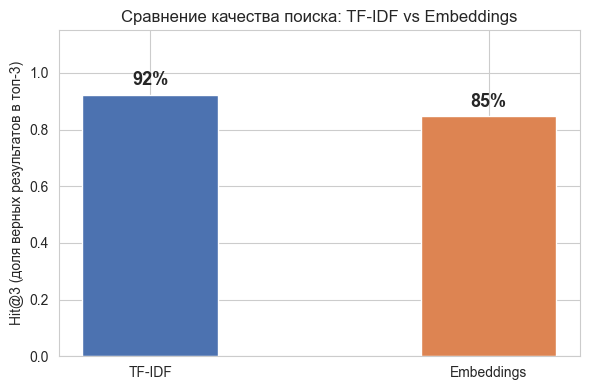

График сохранён в artifacts/comparison_hit3.png


In [11]:
# Столбчатая диаграмма: Hit@3 для TF-IDF vs Embeddings
n = len(test_cases)
methods = ['TF-IDF', 'Embeddings']
scores  = [tfidf_hits / n, emb_hits / n]
colors  = ['#4C72B0', '#DD8452']

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, scores, color=colors, width=0.4, edgecolor='white')

# Подписи над столбиками
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{score:.0%}',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.ylim(0, 1.15)
plt.ylabel('Hit@3 (доля верных результатов в топ-3)')
plt.title('Сравнение качества поиска: TF-IDF vs Embeddings')
plt.tight_layout()
plt.savefig('../artifacts/comparison_hit3.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён в artifacts/comparison_hit3.png')

## 5. Сохранение модели

In [12]:
emb.save('../artifacts/embeddings_model.pkl')
print('Готово!')

Эмбеддинги сохранены: ../artifacts/embeddings_model.pkl
Готово!


## 6. Выводы

| Метод | Принцип | Hit@3 | Скорость обучения |
|-------|---------|-------|-------------------|
| TF-IDF | Частота слов | см. выше | Мгновенно |
| Embeddings | Семантика (смысл) | см. выше | Несколько секунд |

**Вывод:** Embeddings показывают лучшее качество особенно на запросах-перефразировках.
Для финального сервиса выбираем **Embeddings** как основной метод поиска.